In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
import torch

In [54]:
data=np.load('/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/data/2025_09_12_CFRP_FBH_diffusivity_stationary_p1.npz',allow_pickle=True)

In [63]:
data['meta']

array([['laser_power', '30.0'],
       ['T1', '20'],
       ['T2', '5'],
       ['T3', '500'],
       ['method', 'LST'],
       ['fps', '50.0'],
       ['height', '480'],
       ['width', '640'],
       ['sequence_length', '525'],
       ['working_distance', '172'],
       ['pos_X', '50.0'],
       ['pos_Y', '0.2'],
       ['point_no', '1'],
       ['points_in_series', '20'],
       ['thickness', '3.5'],
       ['size_X', '0.30000000000000004'],
       ['size_Y', '0.4'],
       ['comments', 'front view'],
       ['time', '23.09.2025/10:05'],
       ['offset_X_start_point', '0.0'],
       ['offset_Y_start_point', '0.0'],
       ['offset_X_end_point', '0.0'],
       ['offset_Y_end_point', '0.0'],
       ['distance_X', '0.1'],
       ['distance_Y', '0.1'],
       ['no_of_points_X', '4.0'],
       ['no_of_points_Y', '5.0'],
       ['IFOV', '0.1']], dtype='<U32')

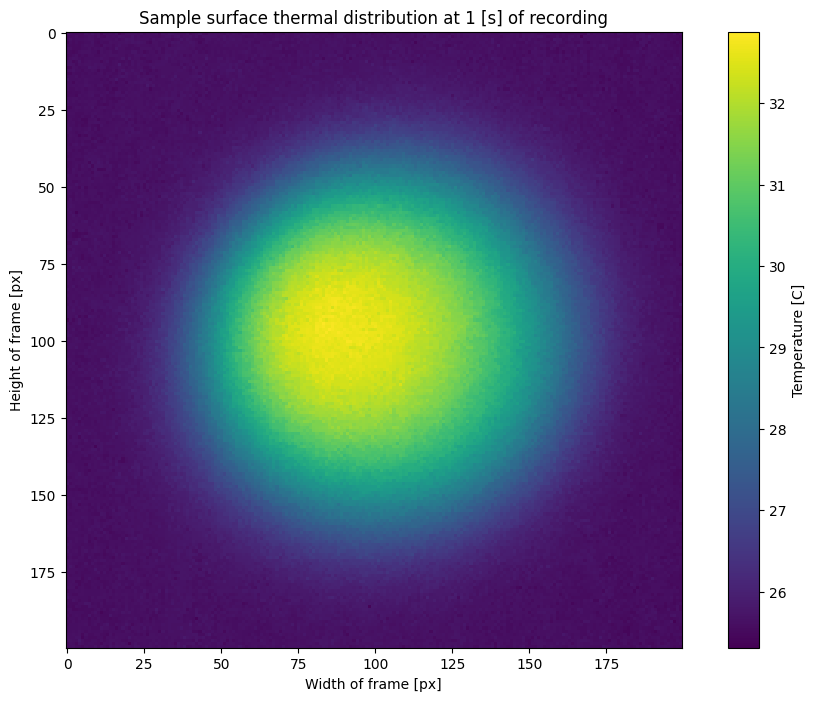

In [55]:
plt.figure(figsize=(12,8))
plt.imshow(data['data'][50,150:350,230:430]/100-273.5)
plt.xlabel('Width of frame [px]')
plt.ylabel('Height of frame [px]')
plt.title('Sample surface thermal distribution at 1 [s] of recording')
plt.colorbar(label='Temperature [C]')

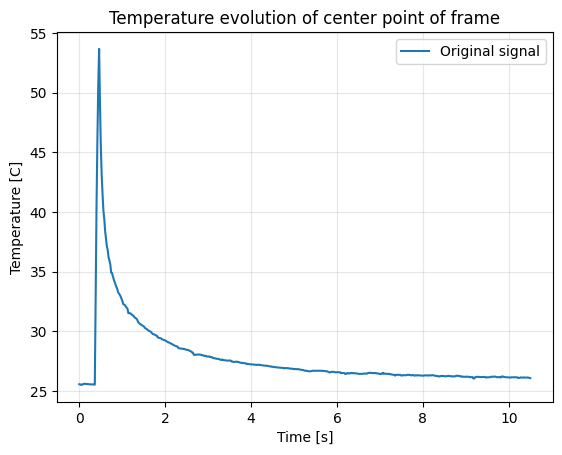

In [56]:
T,H,W=data['data'].shape
H_center=H//2
W_center=W//2

x_t=data['data'][:,H_center,W_center]/100-273.5 # Conversion to the [C]
t=np.linspace(0,T/50,T)

x_t_sav = savgol_filter(x_t, window_length=5, polyorder=3, axis=0)

plt.plot(t,x_t,label='Original signal')
# plt.plot(t,x_t_sav,label='Filtered signal')

plt.grid(alpha=0.3)
plt.xlabel('Time [s]')
plt.ylabel('Temperature [C]')
plt.title('Temperature evolution of center point of frame')
plt.legend()

In [57]:
data['data'].shape

(525, 480, 640)

In [2]:
t_loss=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch_laser_big_data_physical_loss/total_loss.pt")
d_loss=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch_laser_big_data_physical_loss/data_loss.pt")
p_loss=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch_laser_big_data_physical_loss/pde_loss.pt")

Text(0.5, 1.0, 'Training of PINN laser excitment')

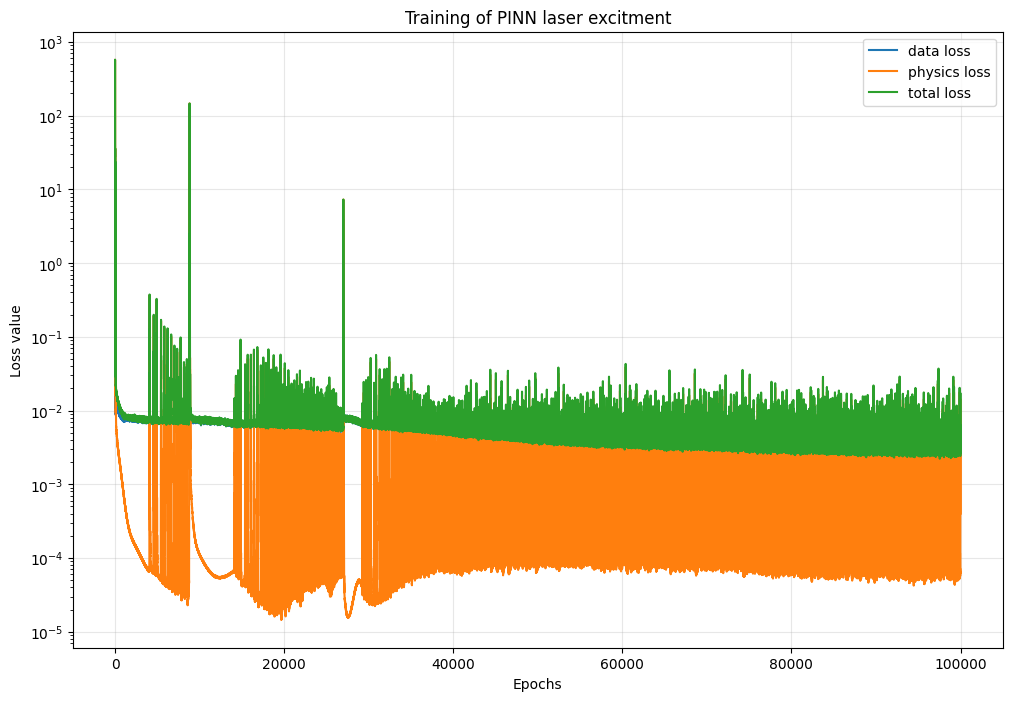

In [8]:
plt.figure(figsize=(12,8))
plt.semilogy(d_loss,label='data loss')
plt.semilogy(p_loss,label='physics loss')
plt.semilogy(t_loss,label='total loss')

plt.legend()
plt.grid(alpha=0.3)
plt.xlabel('Epochs')
plt.ylabel('Loss value')
plt.title('Training of PINN laser excitment')

In [5]:
a_x_track=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch_laser_big_data_physical_loss/a_x_track.pt")
a_y_track=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch_laser_big_data_physical_loss/a_y_track.pt")
a_z_track=torch.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/PINN_1_weights_10000_epoch_laser_big_data_physical_loss/a_z_track.pt")

Text(0.5, 1.0, 'Diffusivity estimation acccross training')

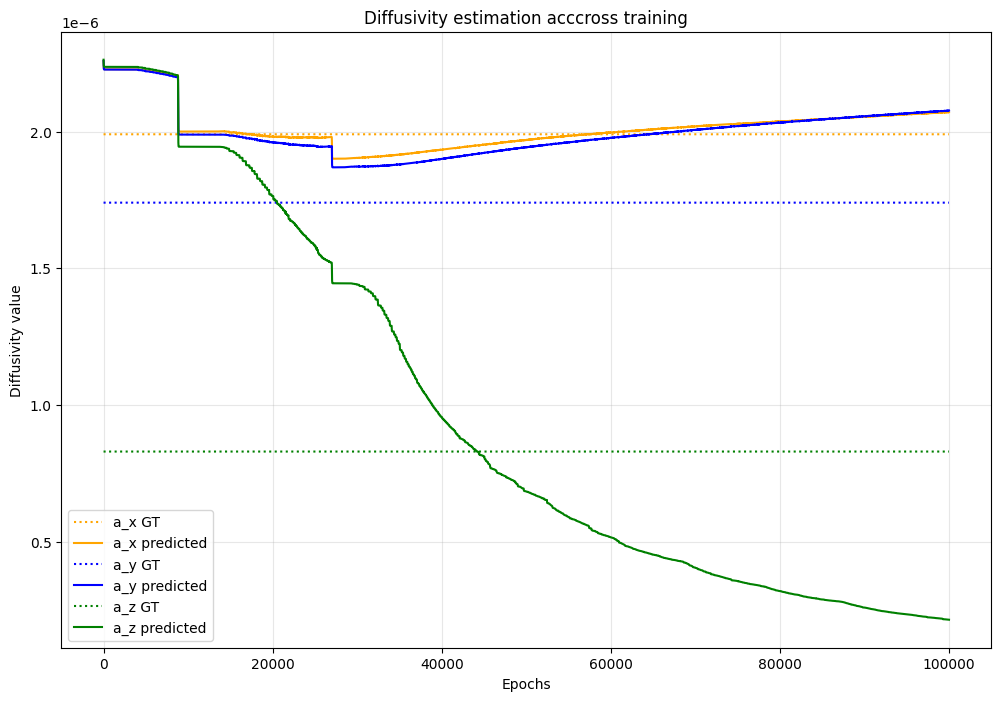

In [7]:
a_x_correct=torch.ones(100000)*1e-6*1.99
a_y_correct=torch.ones(100000)*1e-6*1.74
a_z_correct=torch.ones(100000)*1e-7*8.30
plt.figure(figsize=(12,8))

plt.plot(a_x_correct,label='a_x GT',linestyle=":",color='orange')
plt.plot(a_x_track,label='a_x predicted',color='orange')

plt.plot(a_y_correct,label='a_y GT',linestyle=":",color='blue')
plt.plot(a_y_track,label='a_y predicted',color='blue')

plt.plot(a_z_correct,label='a_z GT',linestyle=":",color='green')
plt.plot(a_z_track,label='a_z predicted',color='green')

plt.legend()
plt.grid(alpha=0.3)
plt.xlabel('Epochs')
plt.ylabel('Diffusivity value')
plt.title('Diffusivity estimation acccross training')